<a href="https://colab.research.google.com/github/JacquelinePantoja/repo_for_DS4PHinP/blob/main/hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
import pandas as pd ## Pandas is our main data cleaning library
import numpy as np ## Numpy is our main numerical library
import matplotlib.pyplot as plt ## Matplotlib is our main plotting library
import seaborn as sns ## Seaborn is a high level plotting library
sns.set()

Load Data

In [12]:
kirb21_df = pd.read_csv("https://raw.githubusercontent.com/smart-stats/ds4bio_book/main/book/assetts/kirby21AllLevels.csv")

Filter to only inlcude one observation

In [68]:
#print(kirb21_df.tail())
kirby906a_ax_df = kirb21_df[kirb21_df["rawid"] == "kirby906a_ax.img"]
kirby906a_ax_df.head()

,Unnamed: 0,rawid,roi,volume,min,max,mean,std,type,level,id,icv,tbv
12540,12541,kirby906a_ax.img,Telencephalon_L,467063,2.0,350.0,165.2599,57.1707,1,1,906,1195015,1123076
12541,12542,kirby906a_ax.img,Telencephalon_R,470488,2.0,337.0,171.8695,59.3001,1,1,906,1195015,1123076
12542,12543,kirby906a_ax.img,Diencephalon_L,8801,60.0,327.0,227.1878,31.2303,1,1,906,1195015,1123076
12543,12544,kirby906a_ax.img,Diencephalon_R,9054,63.0,415.0,231.6770,31.1780,1,1,906,1195015,1123076
12544,12545,kirby906a_ax.img,Mesencephalon,9564,86.0,352.0,269.1003,28.6454,1,1,906,1195015,1123076


1. Write code to calculate this subject's volume of their type I level I telencephalon (left and right). Name the variables "telencephalon_L_volume" and "telencephalon_R_volume" such that when printed only the volume is printed (do not make it a dataframe, series, etc. only a number!). Also, find and print out the fractions of the ICV and TBV made up by their telencelphalon.
2. Create a dataframe that has the sum of all of the regions for every combination of type and level, name it "all_regions_df". So, it should have three columns, type, level and total_volume.

In [69]:
kirby906a_ax_df = kirby906a_ax_df.assign(telencephalon_L_volume = kirby906a_ax_df[kirby906a_ax_df["roi"] == "Telencephalon_L"]["volume"].item())
kirby906a_ax_df = kirby906a_ax_df.assign(telencephalon_R_volume = kirby906a_ax_df[kirby906a_ax_df["roi"] == "Telencephalon_R"]["volume"].item())
print("#this is the Left telencephalon volume, proportion of ICV, and proportion of TBV")
print(kirby906a_ax_df["telencephalon_L_volume"].iloc[0])
# index using ".iloc[]"
print(kirby906a_ax_df["telencephalon_L_volume"].iloc[0]/kirby906a_ax_df["tbv"].iloc[0])
print(kirby906a_ax_df["telencephalon_L_volume"].iloc[0]/kirby906a_ax_df["icv"].iloc[0])

print("#this is the Right telencephalon volume, proportion of ICV, and proportion of TBV")
print(kirby906a_ax_df["telencephalon_R_volume"].iloc[0])
print(kirby906a_ax_df["telencephalon_R_volume"].iloc[0]/kirby906a_ax_df["tbv"].iloc[0])
print(kirby906a_ax_df["telencephalon_R_volume"].iloc[0]/kirby906a_ax_df["icv"].iloc[0])

#this is the Left telencephalon volume, proportion of ICV, and proportion of TBV
467063
0.4158783555164566
0.3908427927682916
#this is the Right telencephalon volume, proportion of ICV, and proportion of TBV
470488
0.41892801555727305
0.3937088655790931


In [87]:
#drop cloumns that are not needed from new df
all_regions_df = kirby906a_ax_df[['type', 'level', 'volume']]


#group by two columns
#"['volume']" tells pandas what to sum by within the subsetted groups
 ##otherwise it sums volume all across
#"reset_index()" binds it back together, it has a weird disjoit look otherwise
all_regions_df = all_regions_df.groupby(['type', 'level'])['volume'].sum().reset_index()
#rename volume to a more descriptive name
all_regions_df=all_regions_df.rename(columns={'volume':'total_volume'})
all_regions_df

,type,level,total_volume
0,1,1,1195015
1,1,2,1195021
2,1,3,1195034
3,1,4,1195065
4,1,5,1195124
5,2,1,1195015
6,2,2,1195022
7,2,3,1195032
8,2,4,1195041
9,2,5,1195092


3. Create a bar plot to visualize this subject's Type 1 Level 2 data using seaborn or matplotlib.
4. Create a donut chart in matplotlib of the Type 1 Level 3 ROI data.
5. Read in the class data from here https://github.com/bcaffo/ds4bme/blob/master/data/classInterests.txt. Name it "class_interests_df". Create a single bar plot of student counts by year and program using seaborn.

/tmp/ipykernel_27771/2121767595.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bplot = sns.barplot(x="roi", y="volume", data=t1l2, palette="flare")


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'CerebralCortex_L'),
  Text(1, 0, 'CerebralCortex_R'),
  Text(2, 0, 'CerebralNucli_L'),
  Text(3, 0, 'CerebralNucli_R'),
  Text(4, 0, 'Thalamus_L'),
  Text(5, 0, 'Thalamus_R'),
  Text(6, 0, 'BasalForebrain_L'),
  Text(7, 0, 'BasalForebrain_R'),
  Text(8, 0, 'Mesencephalon_L'),
  Text(9, 0, 'Mesencephalon_R'),
  Text(10, 0, 'Metencephalon_R'),
  Text(11, 0, 'Metencephalon_L'),
  Text(12, 0, 'Myelencephalon_L'),
  Text(13, 0, 'Myelencephalon_R'),
  Text(14, 0, 'WhiteMatter_L'),
  Text(15, 0, 'WhiteMatter_R'),
  Text(16, 0, 'Ventricle'),
  Text(17, 0, 'Sulcus_L'),
  Text(18, 0, 'Sulcus_R')])

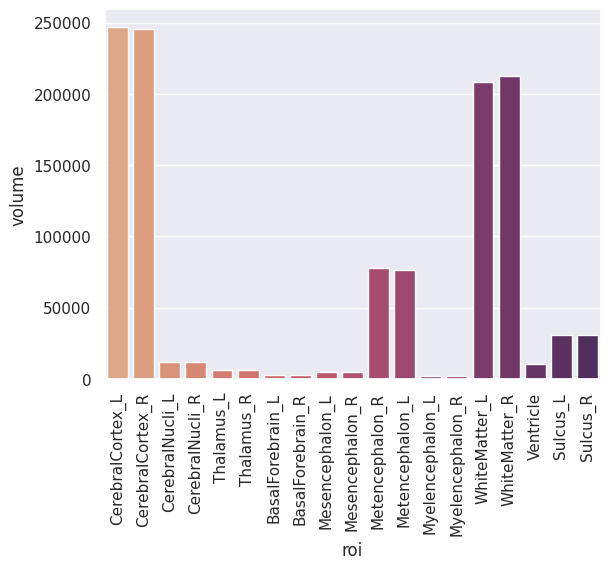

In [95]:
t1l2 = kirby906a_ax_df[(kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 2)]
bplot = sns.barplot(x="roi", y="volume", data=t1l2, palette="flare")
plt.xticks(rotation=90)

In [118]:
#explode = [0.02] * 54

Text(0.5, 1.0, 'Volume by ROI')

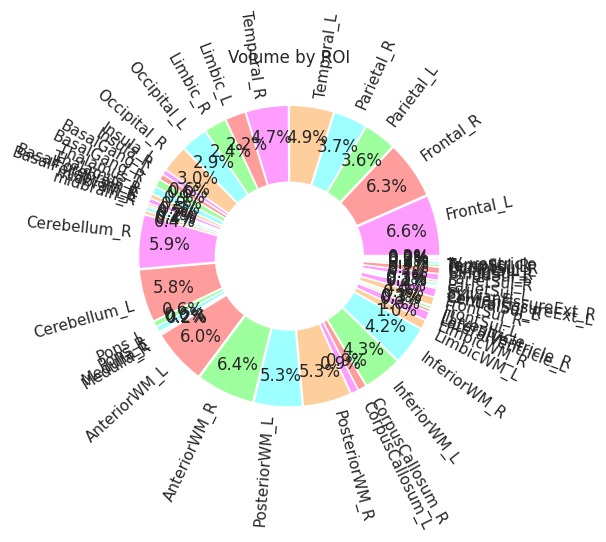

In [121]:
t1l3 = kirby906a_ax_df[(kirby906a_ax_df['type'] == 1) & (kirby906a_ax_df['level'] == 3)]


# colors
colors = ['#ff9dff', '#ff9d9d', '#9dff9d',
          '#9dffff', '#ffce9d']
# explosion
explode = [0.02] * 54

# Pie Chart
plt.pie("volume", colors=colors, labels="roi",
        autopct='%1.1f%%', pctdistance=0.79,
        explode=explode, data=t1l3, rotatelabels=True, labeldistance=1.05)

# draw circle
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
fig = plt.gcf()

# Adding Circle in Pie chart
fig.gca().add_artist(centre_circle)

# Adding Title of chart
plt.title('Volume by ROI')


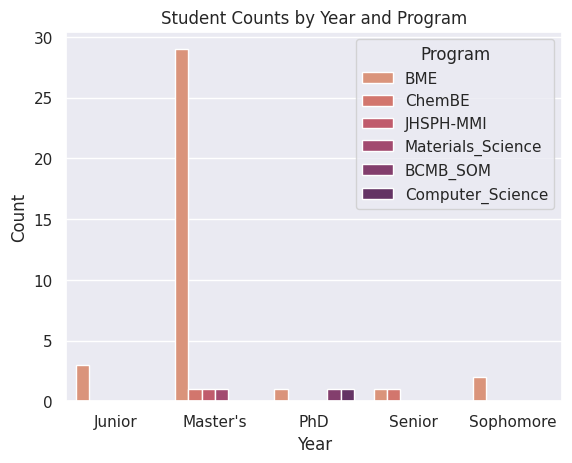

In [137]:
class_interests_df = pd.read_csv('/content/classInterests.txt')

# Split the 'Year\tProgram' column into 'Year' and 'Program'
class_interests_df[['Year', 'Program']] = class_interests_df['Year\tProgram'].str.split('\t', expand=True)

# Count student occurrences by Year and Program size give you the count of rows while naming happens inside the index f
class_interests_df = class_interests_df.groupby(['Year', 'Program']).size().reset_index(name='Count')
sns.barplot(data=class_interests_df, x='Year', y='Count', hue='Program', palette='flare')
plt.title('Student Counts by Year and Program')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

In [138]:
#class_interests_df.head()

6. Download the gene expression dataset from here. Name it "gene_expression_df". Information about the data can be found in the sample info here. Do the following operations in order on the gene expression matrix (please note that 2 uses the matrix created in 1 and 3 uses the matrix created in 2):

subtract the rowmean from each row (name it "gene_expression_df_pt1")

take the resulting matrix and subtract the column mean from each column (name it "gene_expression_df_pt2")

Take the resulting matrix and divide each column by the column's standard deviation (name it "gene_expression_df_pt3")

In [152]:
gene_expression_df.head()
#len(gene_expression_df)
#gene_expression_df.columns

,Unnamed: 0,GSM25581.CEL.gz,GSM25681.CEL.gz,GSM136524.CEL.gz,GSM136707.CEL.gz,GSM25553.CEL.gz,GSM136676.CEL.gz,GSM136711.CEL.gz,GSM136542.CEL.gz,GSM136535.CEL.gz,...,GSM48650.CEL.gz,GSM25687.CEL.gz,GSM25685.CEL.gz,GSM136549.CEL.gz,GSM25427.CEL.gz,GSM25525.CEL.gz,GSM25349.CEL.gz,GSM136727.CEL.gz,GSM25626.CEL.gz,GSM136725.CEL.gz
0,1007_s_at,6.333951,5.736190,6.156754,6.513010,6.061013,6.506493,6.863426,6.369645,6.646321,...,7.082636,6.315866,7.010165,6.460107,6.122355,6.330314,6.627014,6.133068,6.419444,6.488579
1,1053_at,7.255622,7.399993,7.491967,7.006123,7.250995,7.082581,6.842236,7.048487,7.042361,...,6.599718,7.412731,7.274429,6.928642,7.168782,7.235648,6.939184,7.280781,6.351776,7.517410
2,117_at,5.760106,4.825169,5.039387,5.414160,5.205697,5.300078,5.099337,5.156459,5.736109,...,6.231457,5.240717,5.275062,5.759827,5.409720,5.491938,5.113570,5.401876,5.537605,5.247190
3,121_at,6.935451,7.025210,7.543667,7.959781,7.223323,8.006816,8.102504,7.434617,7.532321,...,8.215096,7.677593,7.923624,7.219401,7.432338,6.785174,7.833862,7.607461,7.302935,7.331864
4,1255_g_at,3.597872,3.108801,3.128269,3.364947,3.125909,3.186834,3.311022,3.092042,3.167737,...,3.331424,3.043856,3.151900,3.132253,3.250600,2.984125,3.152269,3.225123,3.222731,3.175846


In [160]:
gene_expression_df = pd.read_csv('/content/GSE5859_exprs.csv')
#gene_expression_df
#gene_expression_pt1 = gene_expression_df.groupby("Unnamed: 0").sum().reset_index()
#gene_expression_df_pt1 = gene_expression_df.assign(gene_expression_pt1 = gene_expression_df.sum()/209)
names = gene_expression_df['Unnamed: 0']
gene_expression_df1 = gene_expression_df.drop(columns=['Unnamed: 0'])
gene_expression_df_pt1 = gene_expression_df1.sub(gene_expression_df1.mean(axis=1), axis=0)


In [162]:
# Subtract the column mean from each column
gene_expression_df_pt2 = gene_expression_df_pt1.sub(gene_expression_df_pt1.mean(axis=0), axis=1)

In [164]:
# Divide by its standard deviation
gene_expression_df_pt3 = gene_expression_df_pt2.div(gene_expression_df_pt2.std(axis=0), axis=1)

# add names column back
gene_expression_df_pt3.insert(0, gene_expression_df.columns[0], names)

7. Download the data from here. Name it "healthcare_df". Create a plot of healthcare spending versus time color coded by states. The option skiprows = 2 is useful in pd.read_csv for this dataset since there's two lines of metadata at the top of the file.
8. Refer to the previous data. Create a barplot using matplotlib of average health care spending by state.

In [179]:
healthcare_df = pd.read_csv('https://raw.githubusercontent.com/jhu-advdatasci/2018/master/data/KFF/healthcare-spending.csv', skiprows=2)

# Filter out metadata rows at the end of the dataframe
healthcare_df = healthcare_df[~healthcare_df['Location'].str.contains('For additional analysis', na=False)]
healthcare_df = healthcare_df[~healthcare_df['Location'].str.contains('Note:', na=False)]

# Identify columns that represent years for melting (all columns except 'Location')
id_vars = ['Location']
value_vars = [col for col in healthcare_df.columns if col not in id_vars]

# Melt the DataFrame to a long format suitable for time series plotting
healthcare_df = healthcare_df.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='Year_Raw', # Temporarily store the original column name
    value_name='Spending'
)

# Extract the year as an integer from the 'Year_Raw' column
healthcare_df['Year'] = healthcare_df['Year_Raw'].str.extract(r'(\d{4})').astype(int)

# Drop the temporary 'Year_Raw' column as 'Year' now holds the integer year
healthcare_df = healthcare_df.drop(columns=['Year_Raw'])

# Display the head of the transformed dataframe
healthcare_df.head()

,Location,Spending,Year
0,United States,675896.0,1991
1,Alabama,10393.0,1991
2,Alaska,1458.0,1991
3,Arizona,9269.0,1991
4,Arkansas,5632.0,1991


<Axes: xlabel='Year', ylabel='Spending'>

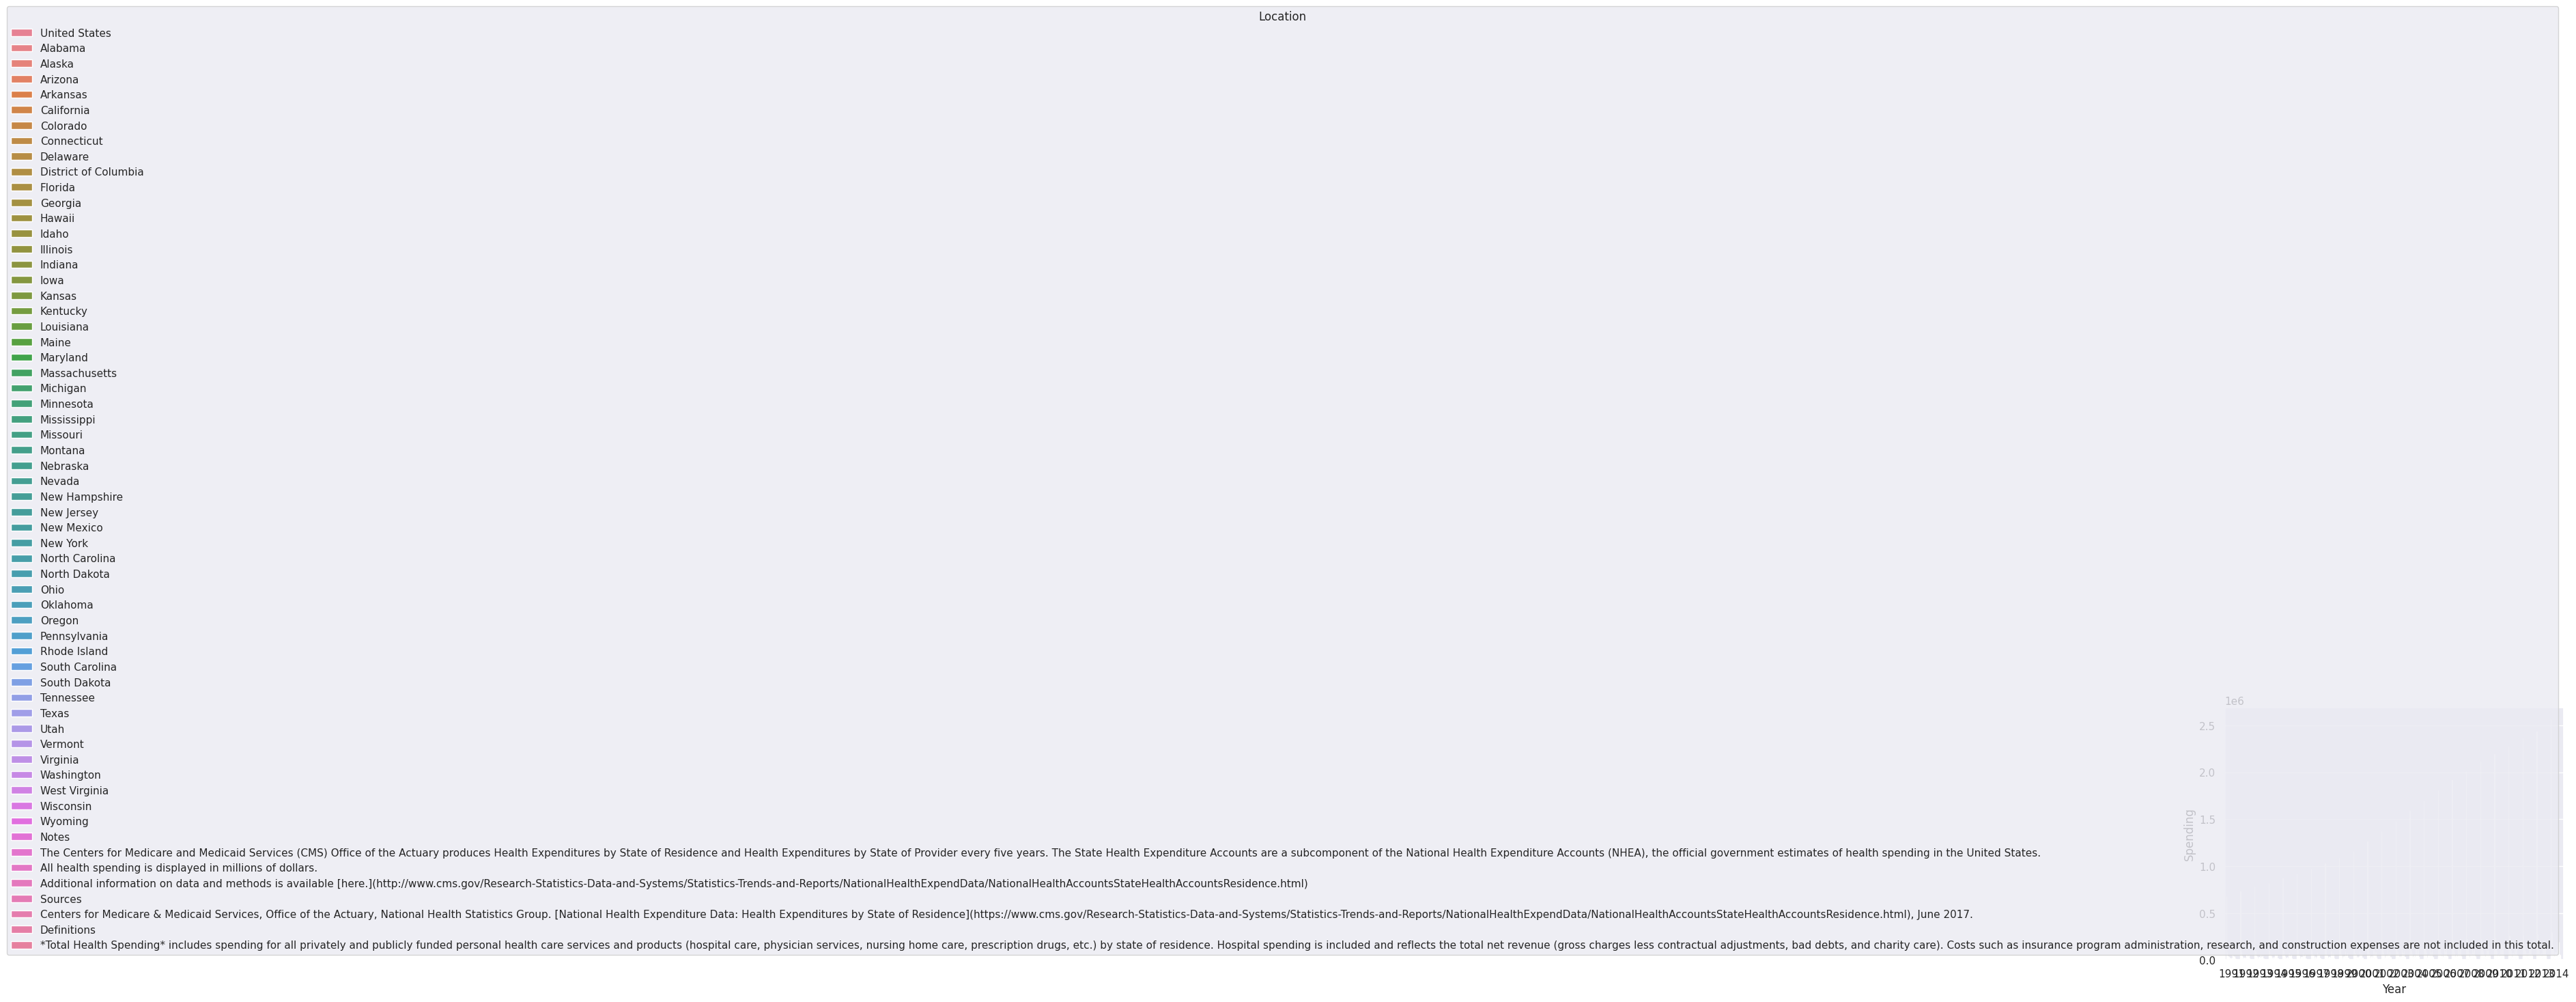

In [182]:
sns.barplot(data=healthcare_df, x='Year', y='Spending', hue='Location')

For this homework, please return a single ipynb file named hw3.ipynb. Do not use plotly for any of the task. Also, submit a pdf printout of your ipynb named hw3.pdf. Use static graphics for this homework (no plotly). Zip your file before submitting.